# 03 - Model Training & Evaluation
Four models are compared; **Random Forest** is the primary model. For at-risk detection we look at **recall of the High class**, not accuracy alone.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display
from src.utils import *
from src import train
table = train.main()
table

[train] RF best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 400}  (cv f1_macro=0.756)


                         Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  High-risk Precision  High-risk Recall  High-risk F1  ROC-AUC (OvR)
Logistic Regression (baseline)    0.7558             0.7239          0.7509      0.7344               0.6721            0.8098        0.7345         0.9082
                 Decision Tree    0.7350             0.7116          0.7300      0.7171               0.6724            0.7610        0.7140         0.8914
       Random Forest (primary)    0.7650             0.7411          0.7426      0.7415               0.7353            0.7317        0.7335         0.9113
                       XGBoost    0.7600             0.7407          0.7464      0.7420               0.7356            0.7463        0.7409         0.9060


[train] artefacts -> /home/claude/Early-Identification-At-Risk-Students/models; scored cohort -> /home/claude/Early-Identification-At-Risk-Students/dataset/students_scored.csv


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),High-risk Precision,High-risk Recall,High-risk F1,ROC-AUC (OvR)
0,Logistic Regression (baseline),0.7558,0.7239,0.7509,0.7344,0.6721,0.8098,0.7345,0.9082
1,Decision Tree,0.7350,0.7116,0.7300,0.7171,0.6724,0.7610,0.7140,0.8914
2,Random Forest (primary),0.7650,0.7411,0.7426,0.7415,0.7353,0.7317,0.7335,0.9113
3,XGBoost,0.7600,0.7407,0.7464,0.7420,0.7356,0.7463,0.7409,0.9060


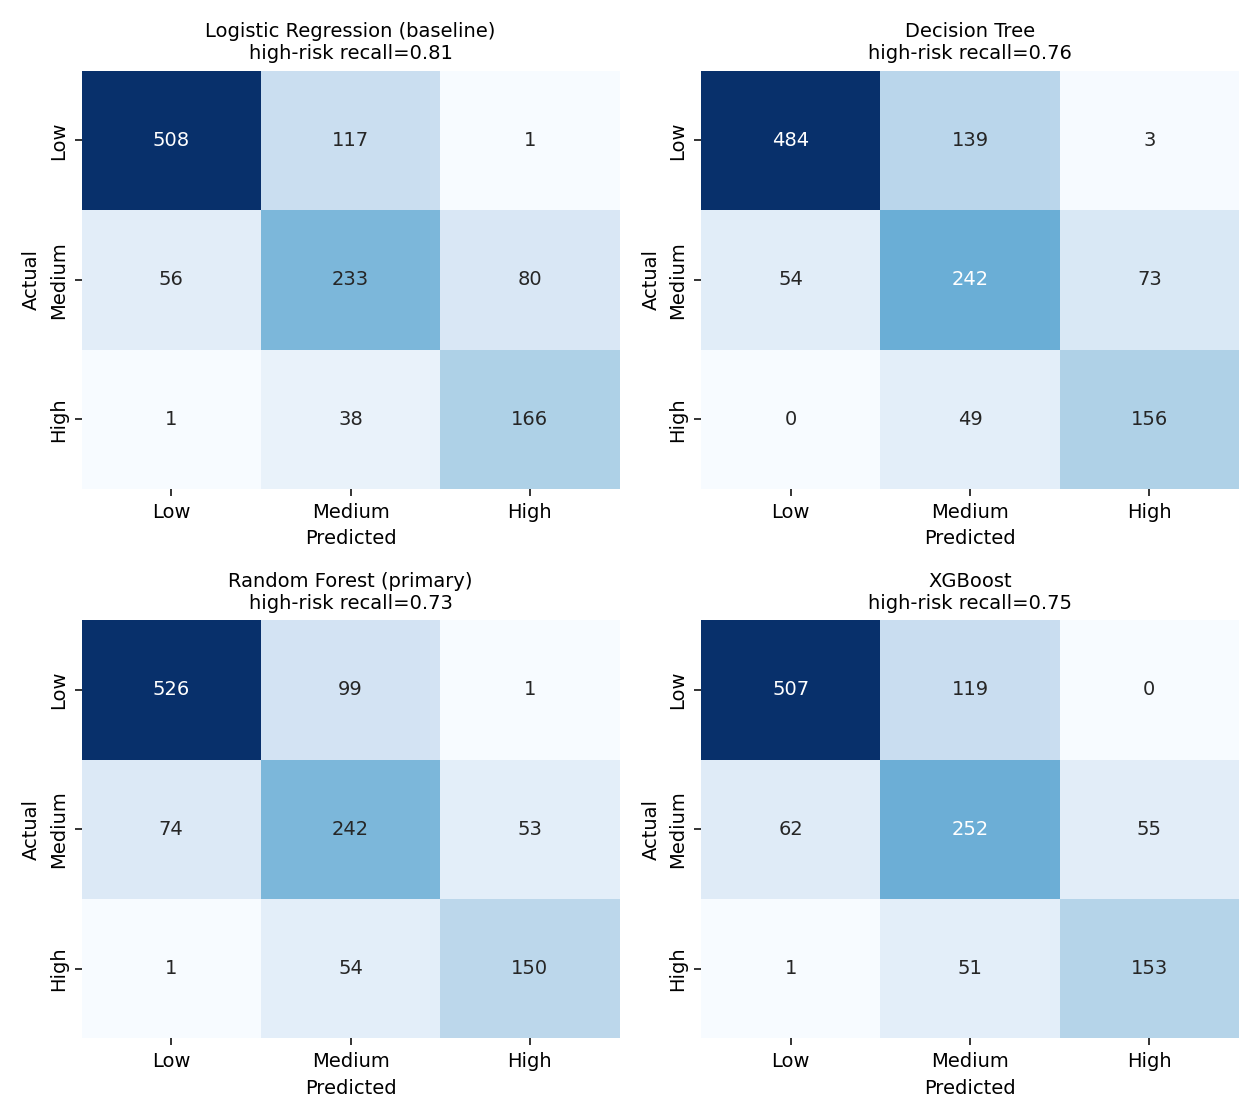

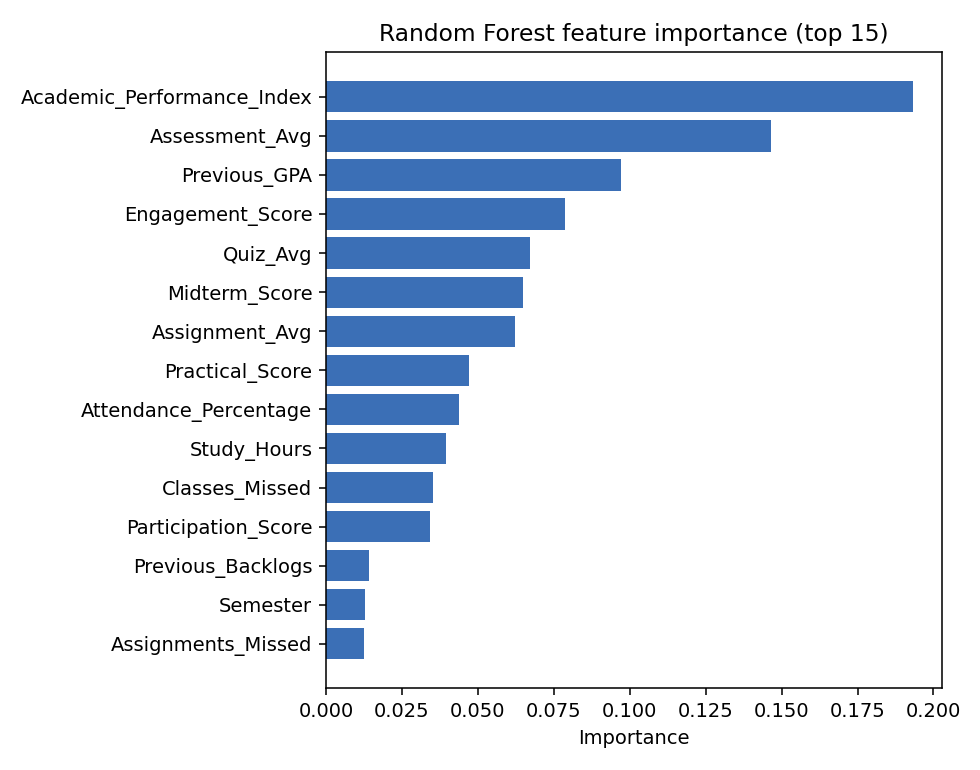

In [2]:
for f in ['confusion_matrices','feature_importance']:
    display(Image(str(FIG_DIR / f'{f}.png'), width=560))

## Score one student (with explanation and support suggestions)

In [3]:
from src.predict import RiskPredictor
RiskPredictor().predict_one({'Attendance_Percentage': 58, 'Previous_GPA': 5.4, 'Assignment_Avg': 46, 'Quiz_Avg': 51,
    'Midterm_Score': 43, 'Study_Hours': 1.5, 'Assignments_Missed': 4, 'Participation_Score': 42})

{'risk': 'High',
 'message': 'High Risk - Immediate Academic Support Recommended',
 'probabilities': {'Low': 0.0,
  'Medium': 0.03904997351172209,
  'High': 0.9609500264882779},
 'factors': [{'factor': 'Low attendance',
   'value': '58%',
   'severity': 'critical'},
  {'factor': 'Low assessment performance',
   'value': '46%',
   'severity': 'critical'},
  {'factor': 'Low previous GPA', 'value': '5.4', 'severity': 'critical'},
  {'factor': 'Multiple missed assignments',
   'value': '4',
   'severity': 'critical'},
  {'factor': 'Low daily study hours',
   'value': '1.5/day',
   'severity': 'critical'},
  {'factor': 'Low class participation',
   'value': '42%',
   'severity': 'critical'}],
 'interventions': ['Faculty mentoring',
  'Weekly academic monitoring',
  'Additional classes / remedial sessions',
  'Assignment completion tracking',
  'Attendance monitoring']}